# Notebook 10 — Advanced Models

## Purpose
I train Random Forest and XGBoost for the prediction tasks, and K-Means for
customer segmentation.  I compare against the baselines from Notebook 09.

## Models
- Random Forest Classifier (sklearn)
- XGBoost Classifier
- K-Means Clustering (on RFM features)

## Inputs
`data/processed/train.parquet`, `data/processed/test.parquet`,
`data/processed/rfm_scores.parquet`

## Outputs
`models/rf_review_model.joblib`, `models/xgb_review_model.joblib`,
`models/rf_late_model.joblib`, `models/advanced_results.json`


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.metrics import bootstrap_metric, permutation_test, macro_f1, model_summary_table
from src.visualization import plot_confusion_matrix, save_fig
from src.utils import set_all_seeds, save_metrics, save_table

cfg   = load_config()
paths = Paths(cfg)
SEED  = cfg['project']['random_seed']
set_all_seeds(SEED)

train = pd.read_parquet(paths.processed / 'train.parquet')
test  = pd.read_parquet(paths.processed / 'test.parquet')
rfm   = pd.read_parquet(paths.processed / cfg['data']['rfm_file'])


Random seed set to 42


In [2]:
# Prepare feature matrices (same as Notebook 09)
FEAT_REVIEW = cfg['modeling']['feature_cols_review']
FEAT_LATE   = cfg['modeling']['feature_cols_late']

train_rv = train.dropna(subset=['review_score'] + FEAT_REVIEW)
test_rv  = test.dropna(subset=['review_score']  + FEAT_REVIEW)
X_tr_rv  = train_rv[FEAT_REVIEW].fillna(0).values
y_tr_rv  = train_rv['review_score'].astype(int).values
X_te_rv  = test_rv[FEAT_REVIEW].fillna(0).values
y_te_rv  = test_rv['review_score'].astype(int).values

train_lt = train.dropna(subset=['is_late'] + FEAT_LATE)
test_lt  = test.dropna(subset=['is_late']  + FEAT_LATE)
X_tr_lt  = train_lt[FEAT_LATE].fillna(0).values
y_tr_lt  = train_lt['is_late'].astype(int).values
X_te_lt  = test_lt[FEAT_LATE].fillna(0).values
y_te_lt  = test_lt['is_late'].astype(int).values

print("Feature matrices ready.")


Feature matrices ready.


In [3]:
# --- Random Forest: Review Score ---
print("Training Random Forest (review score)...")
rf_rv = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)
rf_rv.fit(X_tr_rv, y_tr_rv)
y_pred_rf_rv = rf_rv.predict(X_te_rv)
rf_rv_acc = accuracy_score(y_te_rv, y_pred_rf_rv)
rf_rv_f1  = macro_f1(y_te_rv, y_pred_rf_rv)
print(f"  Accuracy: {rf_rv_acc:.4f}   Macro F1: {rf_rv_f1:.4f}")


Training Random Forest (review score)...
  Accuracy: 0.5493   Macro F1: 0.2924


In [4]:
# --- XGBoost: Review Score ---
print("Training XGBoost (review score)...")
xgb_rv = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
# XGBoost expects 0-indexed classes
xgb_rv.fit(X_tr_rv, y_tr_rv - 1)
y_pred_xgb_rv = xgb_rv.predict(X_te_rv) + 1
xgb_rv_acc = accuracy_score(y_te_rv, y_pred_xgb_rv)
xgb_rv_f1  = macro_f1(y_te_rv, y_pred_xgb_rv)
print(f"  Accuracy: {xgb_rv_acc:.4f}   Macro F1: {xgb_rv_f1:.4f}")


Training XGBoost (review score)...
  Accuracy: 0.6238   Macro F1: 0.2551


In [5]:
# --- Random Forest: Late Delivery ---
print("Training Random Forest (late delivery)...")
rf_lt = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=5,
    class_weight='balanced', random_state=SEED, n_jobs=-1,
)
rf_lt.fit(X_tr_lt, y_tr_lt)
y_pred_rf_lt = rf_lt.predict(X_te_lt)
rf_lt_acc = accuracy_score(y_te_lt, y_pred_rf_lt)
rf_lt_f1  = macro_f1(y_te_lt, y_pred_rf_lt)
print(f"  Accuracy: {rf_lt_acc:.4f}   Macro F1: {rf_lt_f1:.4f}")


Training Random Forest (late delivery)...
  Accuracy: 0.9226   Macro F1: 0.4799


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\confusion_matrix_rf_review.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\confusion_matrix_rf_review.png


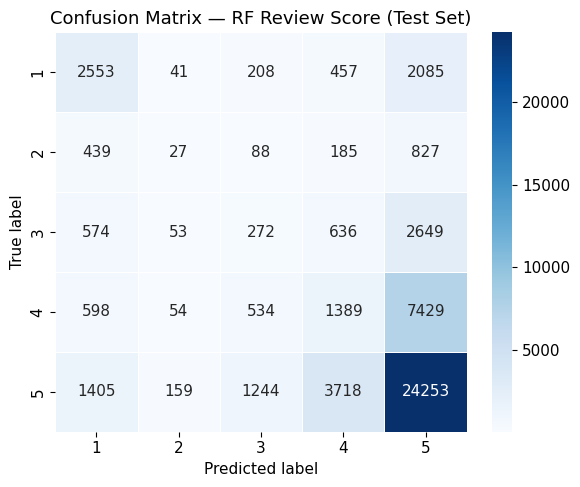

In [6]:
# --- Confusion matrix for best review model (RF) ---
cm = confusion_matrix(y_te_rv, y_pred_rf_rv)
fig = plot_confusion_matrix(cm, labels=[1,2,3,4,5],
    title='Confusion Matrix — RF Review Score (Test Set)',
    save_name='confusion_matrix_rf_review',
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


In [7]:
# --- K-Means on RFM ---
print("Running K-Means on RFM features...")
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score

rfm_features = rfm[['recency', 'frequency', 'monetary']].copy()
scaler_rfm = RobustScaler()
X_rfm = scaler_rfm.fit_transform(rfm_features)

# Try k = 3, 4, 5 and pick by silhouette score
sil_scores = {}
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_rfm)
    sil = silhouette_score(X_rfm, labels, sample_size=5000, random_state=SEED)
    sil_scores[k] = sil
    print(f"  k={k}: silhouette = {sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k by silhouette: k={best_k}")


Running K-Means on RFM features...
  k=3: silhouette = 0.6525
  k=4: silhouette = 0.4965
  k=5: silhouette = 0.3839
  k=6: silhouette = 0.3993

Best k by silhouette: k=3


In [8]:
# Fit best K-Means
km_best = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
rfm['kmeans_cluster'] = km_best.fit_predict(X_rfm)
print("K-Means cluster sizes:")
print(rfm['kmeans_cluster'].value_counts().sort_index())
# Describe clusters
for c in sorted(rfm['kmeans_cluster'].unique()):
    row = rfm[rfm['kmeans_cluster']==c][['recency','frequency','monetary']].mean()
    print(f"  Cluster {c}: recency={row['recency']:.0f}d  freq={row['frequency']:.2f}  monetary=R${row['monetary']:.0f}")


K-Means cluster sizes:
kmeans_cluster
0      851
1    84100
2     8407
Name: count, dtype: int64
  Cluster 0: recency=238d  freq=1.08  monetary=R$1680
  Cluster 1: recency=238d  freq=1.03  monetary=R$93
  Cluster 2: recency=239d  freq=1.11  monetary=R$474


In [9]:
# Save models
paths.models.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_rv, paths.models / 'rf_review_model.joblib')
joblib.dump(xgb_rv, paths.models / 'xgb_review_model.joblib')
joblib.dump(rf_lt, paths.models / 'rf_late_model.joblib')
print("Models saved.")

# Save advanced results
n_boot = cfg['modeling']['n_bootstrap']
n_perm = cfg['modeling']['n_permutations']
rf_ci   = bootstrap_metric(y_te_rv, y_pred_rf_rv,  n_bootstrap=n_boot, seed=SEED)
xgb_ci  = bootstrap_metric(y_te_rv, y_pred_xgb_rv, n_bootstrap=n_boot, seed=SEED)
rf_perm = permutation_test(y_te_rv, y_pred_rf_rv,   n_permutations=n_perm, seed=SEED)

advanced_results = {
    'task_review_score': {
        'random_forest': {**rf_ci,  'macro_f1': rf_rv_f1,  'permutation_p': rf_perm['p_value']},
        'xgboost':       {**xgb_ci, 'macro_f1': xgb_rv_f1},
    },
    'task_late_delivery': {
        'random_forest': {'accuracy': rf_lt_acc, 'macro_f1': rf_lt_f1},
    },
    'clustering': {
        'best_k': best_k,
        'silhouette_scores': sil_scores,
    }
}
save_metrics(advanced_results, paths.models / 'advanced_results.json')
print("Notebook 10 complete.")


Models saved.
  Saved metrics: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\models\advanced_results.json
Notebook 10 complete.
